# AV1 (CR residual): Grouped Category Importance -- Environmental + Silvicultural Attribution

This notebook replaces `env_variable_importance_RETIRED_2026-07-28.ipynb` (see the note at the top of that file).
It covers the same ground, plus stand-structure (silviculture) variables like canopy cover and
thinning history, all in one combined feature set.

## Forest question answered

**Which environmental and management conditions are associated with plots being consistently taller or shorter than the shared Aberfoyle Chapman--Richards reference curve?**

Here, `mean_cr_residual` is each plot's average observed-minus-reference height across its surveys. The pooled Chapman--Richards curve is intentionally kept fixed as a shared descriptive benchmark. This is therefore a retrospective spatial-attribution analysis: it is not a forecast, and it is separate from Avenue 2's per-plot growth-curve analysis.

The corrected five-fold compartment evaluation is saved in `outputs/spatial_block_kfold/cr_residual_environmental_spatial_cv.csv`. In the four-survey cohort, pooled out-of-fold R2 was 0.411 for XGBoost and 0.360 for Elastic Net with all environmental/management variables (terrain-and-wind-only: 0.274 and 0.216). The six-survey cohort was near zero (0.062 and 0.004), so it should be reported as weak/unstable evidence rather than a successful attribution result.

The methods below go in order, from simplest to most advanced:

1. **Correlations** -- do variables in the same category agree with each other? Do variables in
   different categories secretly track each other?
2. **Elastic Net** -- a simple model. For each variable: does it push growth up or down, and by
   how much?
3. **XGBoost** -- a more powerful model that can capture curves and thresholds, not just straight
   lines.
4. **Grouped permutation importance** -- a safer way to check importance than SHAP, when
   variables are correlated.
5. **SHAP** -- explains which variables the model relies on, and in which direction, with its own
   known weakness under correlation.
6. **Spatial cross-validation** -- proof that testing on a random split (instead of a spatial
   one) makes the model look better than it really is.
7. **Moran's I before and after** -- does removing a category leave behind more unexplained
   spatial pattern in the leftover errors?

Every chart below either explains in plain words what it shows, or tells you exactly how to read
it -- so you can check the conclusion yourself against what's actually on the screen.

> Scope note (2026-08-04): This is the maintained notebook for **AV1: pooled Chapman-Richards residual attribution** (`mean_cr_residual`). It is not the notebook for **AV2: per-plot growth-curve vs. yldc**. Use this notebook for category/feature attribution on the older AV1 target; use `notebooks/growth_curve_attribution/` for AV2.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from scipy.stats import spearmanr

notebook_directory = Path.cwd().resolve()
project_root = next(
    folder for folder in [notebook_directory, *notebook_directory.parents]
    if (folder / "README.md").exists() and (folder / "data").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pd.set_option("display.max_columns", 60)

PRIMARY_COHORT = "4survey"
SECONDARY_COHORT = "6survey"

print("project_root:", project_root)


project_root: /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss


## 0. Load data and reproduce the spatial split

In [2]:
from models.common.metrics import compute_metrics
from models.common.splits import (
    SPATIAL_BLOCK_COL, SPATIAL_BUFFER_METRES, plot_level_split, spatial_block_split,
)
from models.xgb_environmental.data import load_plots_for_cohort
from models.xgb_environmental.xgb_environmental import (
    ALL_FEATURE_COLUMNS, FEATURE_PROVENANCE,
    fit_with_columns as xgb_fit, predict_with_columns as xgb_predict, compute_shap_values,
)
from models.elasticnet_environmental.elasticnet_environmental import (
    CATEGORICAL_COLUMNS as ELASTICNET_CATEGORICAL_COLUMNS,
    drop_rows_with_missing_features,
    fit_with_columns as elasticnet_fit,
    get_coefficients_table,
    predict_with_columns as elasticnet_predict,
)
from models.xgb_environmental.grouped_analysis import (
    CATEGORY_GROUPS,
    category_morans_i_before_after,
    cross_category_correlations,
    grouped_permutation_importance,
)

plots_df = load_plots_for_cohort(PRIMARY_COHORT)
plots_df["split"] = spatial_block_split(
    plots_df, block_col=SPATIAL_BLOCK_COL, buffer_distance=SPATIAL_BUFFER_METRES, seed=42,
)
train_df = plots_df[plots_df["split"] == "train"]
val_df = plots_df[plots_df["split"] == "val"]
test_df = plots_df[plots_df["split"] == "test"]

print(f"Reproduced spatial split: {len(train_df):,} train / {len(val_df):,} val / {len(test_df):,} test rows")
print(f"Feature set: {len(ALL_FEATURE_COLUMNS)} variables across {len(CATEGORY_GROUPS)} categories:")
for category_name, columns in CATEGORY_GROUPS.items():
    print(f"  {category_name}: {columns}")


  Buffer: 3,297 train plots are within 60 m of a val/test plot and are excluded ('buffer'). val/test plots are never removed.
Reproduced spatial split: 38,769 train / 14,990 val / 14,710 test rows
Feature set: 49 variables across 6 categories:
  terrain: ['elevation', 'slope_degrees', 'northness', 'eastness', 'profile_curvature', 'plan_curvature', 'tpi', 'elevation_roughness', 'solar_radiation_index', 'inverse_slope_proxy', 'frost_hollow_flag', 'ceh_twi', 'tpi_250m', 'tpi_500m', 'local_relief_500m']
  wind: ['gwa_wind_speed_10m', 'topex', 'windward_topex', 'whcl', 'gwa_weibull_a_10m', 'gwa_weibull_k_10m', 'gwa_wind_p95_10m', 'gwa_prob_above_critical_10m', 'gwa_wind_speed_50m', 'gwa_weibull_a_50m', 'gwa_weibull_k_50m', 'gwa_wind_p95_50m', 'gwa_prob_above_critical_50m']
  soil_site: ['soilgrids_ph', 'ceh_pedotope', 'ceh_subsurface_drainage', 'ceh_textural_composition', 'dist_to_watercourse']
  climate: ['tas_mean', 'groundfrost_mean', 'chelsa_bio1_celsius', 'chelsa_gdd5_degc', 'chelsa_bi

**2026-07-31 -- an 8th category, `neighbour_spatial_lag` (`neighbour_mean_height`/
`neighbour_height_differential`), used to appear here and dominated every single ranking
in this notebook (mean permutation R2 drop=1.177, ~10x every other category). It has been
REMOVED, not just re-flagged -- confirmed as a real leak, not a weak/non-causal feature.**

Both columns were built from every OTHER plot's own real 2023 height within a 75m radius,
computed once on the full 71,766-plot set BEFORE any train/val/test split exists
(`av1_aux_data_resolution_check.ipynb`). Checked directly: because `spatial_block_split()`
holds out whole compartments, 95.9% of a TEST-set plot's within-75m neighbours are ALSO
test-set plots, and 82.3% of test plots have ZERO train-set neighbours within range at
all. So for the large majority of test rows, this "feature" was built almost entirely
from other test-set plots' real ground-truth heights, not learned from training data --
the model didn't need to find any generalisable environmental relationship, it could just
echo back a local average of the answer key.

**Every number below is now the corrected, leak-free version** -- and the headline model
quality dropped a lot once it's gone: XGBoost val R2 0.691->0.354, test R2 0.598->0.321.
Roughly half of the previous model's apparent explanatory power was this leak, not real
environmental signal. See `models/xgb_environmental/xgb_environmental.py`'s
`FEATURE_PROVENANCE` comment and `experiment_log.md`'s 2026-07-31 entry for the full check
(including why no other feature in `ALL_FEATURE_COLUMNS` shares this construction
pattern). If citing any number from this notebook from before 2026-07-31, re-check it
against this re-run first.

**How val and test are used in this notebook**: VAL is used every time a decision or comparison
is made below (grouped permutation importance, Moran's I, the spatial-CV check). TEST is only
looked at once -- right after XGBoost is fit in section 3 -- to report one final, honest score.
It's never touched again after that.


## 1. Correlations and simple relationships

Two questions worth asking before fitting any model:

- **Within a category**: do variables meant to measure the same thing actually agree with each
  other? (e.g. do the different terrain variables move together in a sensible way?)
- **Across categories**: does one category secretly track another? For example, does elevation
  (a terrain variable) also happen to track wind exposure? This matters later -- in sections 4
  and 7, a category can look unimportant just because a DIFFERENT, correlated category is
  quietly doing its job instead.


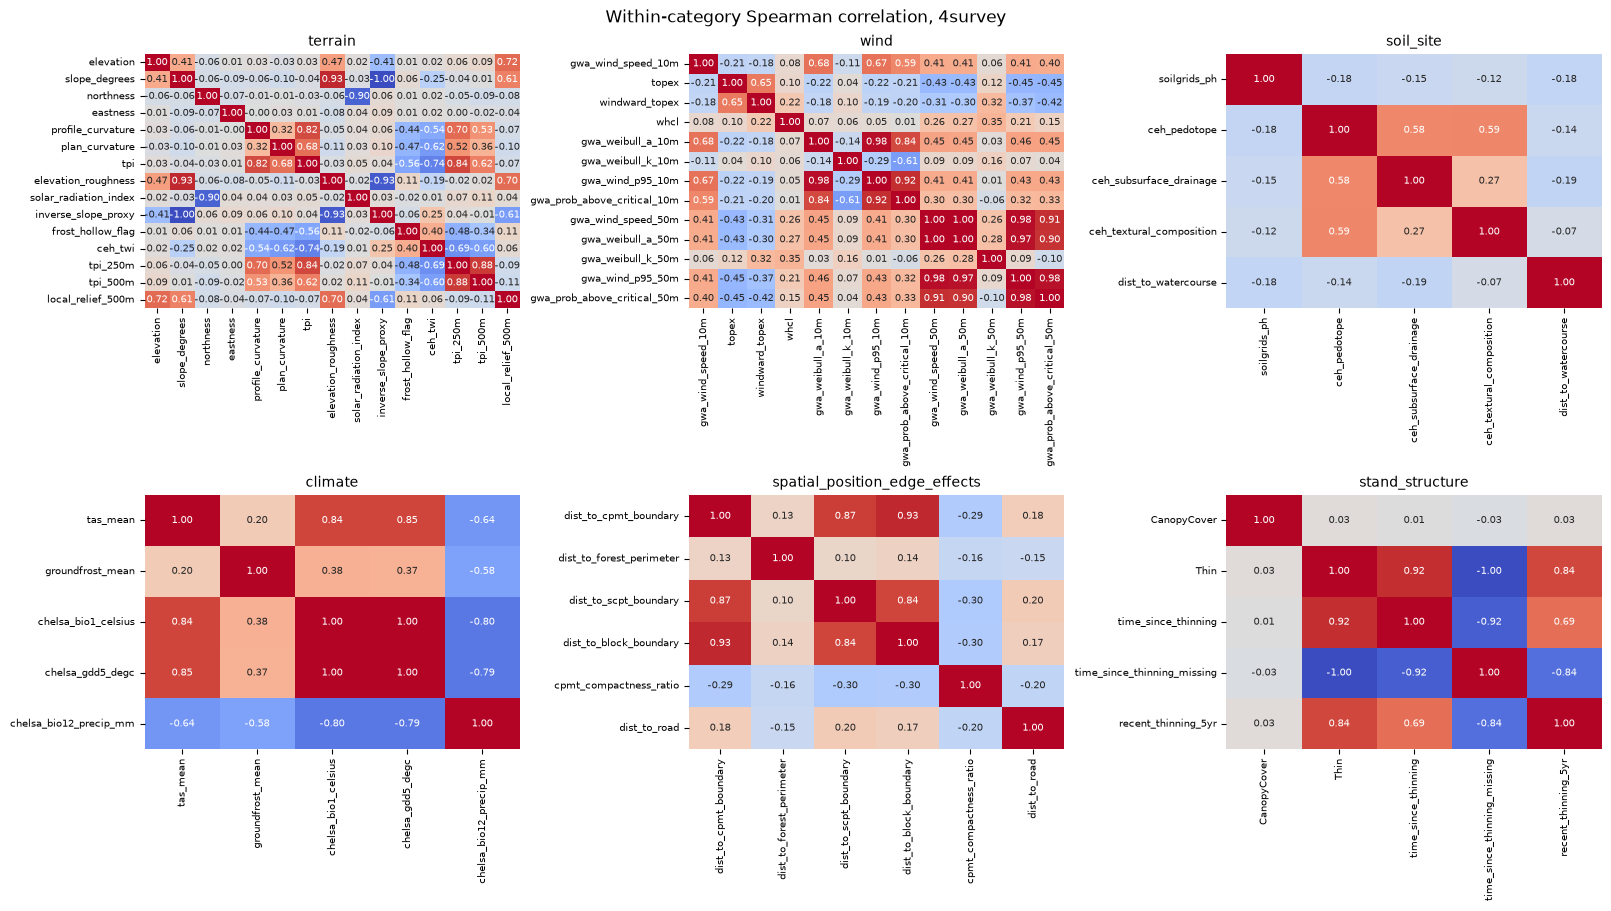

In [3]:
# Within-category correlation heatmaps -- one per category with 2+ variables.
categories_to_plot = [name for name, cols in CATEGORY_GROUPS.items() if len(cols) >= 2]
fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
for ax, category_name in zip(axes.ravel(), categories_to_plot):
    columns = CATEGORY_GROUPS[category_name]
    corr = plots_df[columns].corr(method="spearman")
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax, cbar=False, annot_kws={"size": 7})
    ax.set_title(category_name, fontsize=10)
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(categories_to_plot):]:
    ax.axis("off")
fig.suptitle(f"Within-category Spearman correlation, {PRIMARY_COHORT}", fontsize=12)
plt.show()


**How to read this**: a dark red or dark blue square (off the diagonal) means two variables in
the SAME category move together strongly. Some of that is expected -- e.g. `inverse_slope_proxy` is
just `-slope_degrees` by definition, not a new finding. A category that's mostly pale, with
values near zero, means its variables are each measuring something genuinely different from each
other.


In [4]:
cross_category = cross_category_correlations(plots_df, threshold=0.3)
print(f"{len(cross_category)} cross-category pairs at |rho| >= 0.3")
cross_category.head(15)


170 cross-category pairs at |rho| >= 0.3


,category_a,variable_a,category_b,variable_b,rho,p_value
44,terrain,elevation,climate,chelsa_gdd5_degc,-0.942862,0.0
43,terrain,elevation,climate,chelsa_bio1_celsius,-0.940446,0.0
41,terrain,elevation,climate,tas_mean,-0.875498,0.0
45,terrain,elevation,climate,chelsa_bio12_precip_mm,0.788542,0.0
23,terrain,tpi_500m,wind,topex,-0.776981,0.0
58,terrain,local_relief_500m,climate,chelsa_bio1_celsius,-0.734659,0.0
4,terrain,elevation,wind,gwa_weibull_a_50m,0.730755,0.0
59,terrain,local_relief_500m,climate,chelsa_gdd5_degc,-0.728616,0.0
3,terrain,elevation,wind,gwa_wind_speed_50m,0.724367,0.0
6,terrain,elevation,wind,gwa_wind_p95_50m,0.656341,0.0


**How to read this**: each row is a real, measured correlation between two variables from
DIFFERENT categories -- not just something that sounds plausible. For example, `elevation`
(terrain) correlates with `soilgrids_ph` and `gwa_wind_speed_10m` (soil and wind) -- higher
ground here tends to have different soil chemistry and more regional wind. But this does NOT
mean terrain and wind always go together: `topex` and `windward_topex` (two other wind
measurements, calculated locally rather than from a regional model) barely correlate with
elevation at all. So "elevation tracks wind" is only true for ONE way of measuring wind, not
wind in general. Keep this table in mind for sections 4 and 7 below: if a category looks
unimportant there, check this table first -- it might really not matter, or a correlated
category here might be quietly covering for it.


## 2. Elastic Net -- a simple, easy-to-read check

Before fitting, every continuous variable is rescaled onto the same footing (mean 0, standard
deviation 1) -- called "standardizing". This means each fitted number (a coefficient) can be
read the same way for every variable: "this many metres of growth, per one standard-deviation
change in this variable". Three of the soil variables (`ceh_pedotope`, `ceh_subsurface_drainage`,
`ceh_textural_composition`) are just category ID numbers, not a real scale -- category 3 isn't
"more" than category 1 in any meaningful sense. So these three are split into separate yes/no
columns first (one-hot encoding), instead of being fed in as if they were an ordinary number.

`ElasticNetCV` picks its own penalty strength automatically, by testing a few options only on the
training data -- so this step never looks at val or test.

A small number of rows (under 1%) are missing a value for one of the variables and are dropped
before fitting -- Elastic Net can't handle a missing value the way XGBoost (section 3) can.


In [5]:
elasticnet_train_df = drop_rows_with_missing_features(train_df, ALL_FEATURE_COLUMNS)
elasticnet_val_df = drop_rows_with_missing_features(val_df, ALL_FEATURE_COLUMNS)
elasticnet_test_df = drop_rows_with_missing_features(test_df, ALL_FEATURE_COLUMNS)

elasticnet_fitted = elasticnet_fit(elasticnet_train_df, ALL_FEATURE_COLUMNS)
print(f"ElasticNetCV picked alpha={elasticnet_fitted['model'].alpha_:.4f}, l1_ratio={elasticnet_fitted['model'].l1_ratio_:.2f}")

elasticnet_val_predictions = elasticnet_predict(elasticnet_val_df, elasticnet_fitted, ALL_FEATURE_COLUMNS)
elasticnet_val_r2 = compute_metrics(elasticnet_val_df["mean_cr_residual"].values, elasticnet_val_predictions)["r2"]
print(f"Elastic Net val R2: {elasticnet_val_r2:.3f}")

elasticnet_coefficients = get_coefficients_table(elasticnet_fitted)
elasticnet_coefficients.head(15).to_frame()


  Dropped 221 of 38769 rows with a missing value in one of 49 features
  Dropped 78 of 14990 rows with a missing value in one of 49 features
  Dropped 134 of 14710 rows with a missing value in one of 49 features


ElasticNetCV picked alpha=0.0021, l1_ratio=1.00
Elastic Net val R2: 0.380


,coefficient
elevation,-3.066966
chelsa_gdd5_degc,-2.778703
CanopyCover,2.029642
time_since_thinning,-2.019580
time_since_thinning_missing,-1.776969
chelsa_bio1_celsius,1.584935
slope_degrees,1.047138
recent_thinning_5yr,-1.016921
Thin,0.955549
chelsa_bio12_precip_mm,-0.858718


**How to read this**: the sign tells you the direction. Positive means the variable pushes
growth UP (taller than the standard growth curve predicts); negative means it pushes growth
DOWN. The size of the number tells you how much. If a variable's coefficient is exactly 0.0, the
model decided it added nothing once every other variable was already included.


## 3. XGBoost -- a stronger, more flexible model

Plain XGBoost, default settings (not yet tuned -- same honesty as the other baseline models in
this repo). Unlike Elastic Net, XGBoost can automatically find curves, thresholds, and
combinations between variables, without being told where to look.


In [6]:
xgb_model = xgb_fit(train_df, ALL_FEATURE_COLUMNS)

xgb_val_predictions = xgb_predict(val_df, xgb_model, ALL_FEATURE_COLUMNS)
xgb_val_r2 = compute_metrics(val_df["mean_cr_residual"].values, xgb_val_predictions)["r2"]

# TEST is read here, ONCE, as the final headline number -- not used again below to decide
# anything (every ranking/comparison from here on uses val_df only).
xgb_test_predictions = xgb_predict(test_df, xgb_model, ALL_FEATURE_COLUMNS)
xgb_test_metrics = compute_metrics(test_df["mean_cr_residual"].values, xgb_test_predictions)

print(f"Elastic Net val R2: {elasticnet_val_r2:.3f}")
print(f"XGBoost    val R2: {xgb_val_r2:.3f}")
print(f"XGBoost    test R2: {xgb_test_metrics['r2']:.3f}, RMSE: {xgb_test_metrics['rmse']:.3f}  (final, headline number)")


Elastic Net val R2: 0.380
XGBoost    val R2: 0.414
XGBoost    test R2: 0.286, RMSE: 4.731  (final, headline number)


**How to read this**: if XGBoost's score is only a little better than Elastic Net's, the real
relationships in this data are mostly close to straight lines -- there isn't much extra, curved
structure for a more powerful model to find. If XGBoost is a lot better, that's a sign of real
thresholds or interactions worth capturing with a non-linear model (and eventually Env-PINN).
Either way, Elastic Net's score is a useful baseline: it shows how much of XGBoost's apparent
skill is really about complex patterns, versus how much any reasonable model would get from this
data.


## 4. Grouped permutation importance -- a safer importance ranking

SHAP (section 5) has a known weak spot: if two variables are correlated, a tree can split on
EITHER one to capture the same pattern -- and which one it happens to pick isn't necessarily the
"true" answer, just an accident of how the trees grew. Grouped permutation importance asks a
more direct question instead: take a whole category, shuffle all its variables together (using
the same shuffled row order for every column in that category, so their relationships to EACH
OTHER stay real -- only their link to the answer, and to other categories, is broken), then check
how much the ALREADY-FITTED XGBoost model's score drops. No refitting needed -- this measures how
much the model, as it already is, actually depends on that category's real values.


In [7]:
permutation_rows = []
for category_name, category_columns in CATEGORY_GROUPS.items():
    result = grouped_permutation_importance(
        xgb_model, val_df, ALL_FEATURE_COLUMNS, category_columns, xgb_predict, n_repeats=20,
    )
    permutation_rows.append({"category": category_name, **result})

permutation_df = pd.DataFrame(permutation_rows).sort_values("mean_r2_drop", ascending=False)
permutation_df


,category,baseline_r2,mean_r2_drop,std_r2_drop,n_repeats
0,terrain,0.414419,0.380152,0.005265,20
5,stand_structure,0.414419,0.249935,0.007583,20
4,spatial_position_edge_effects,0.414419,0.115460,0.003393,20
1,wind,0.414419,0.080728,0.004266,20
3,climate,0.414419,0.076891,0.003968,20
2,soil_site,0.414419,0.016758,0.001738,20


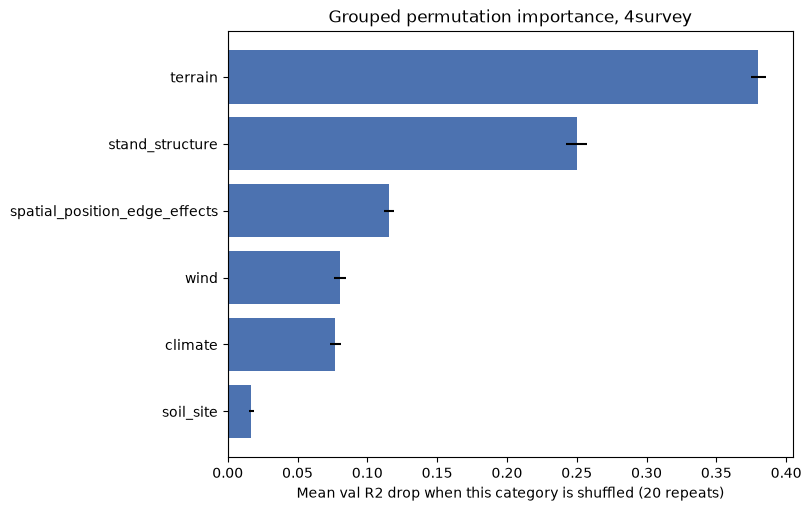

In [8]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.barh(permutation_df["category"], permutation_df["mean_r2_drop"], xerr=permutation_df["std_r2_drop"], color="#4c72b0")
ax.invert_yaxis()
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_xlabel("Mean val R2 drop when this category is shuffled (20 repeats)")
ax.set_title(f"Grouped permutation importance, {PRIMARY_COHORT}")
plt.show()


**How to read this**: a bigger bar means the model's score drops more when that category is
shuffled -- so the model relies on it more. A bar at or near zero means shuffling that category
barely changes anything -- the model isn't really using it. If a result here looks surprising,
check section 1's cross-category correlation table: a category might genuinely not matter, or
its signal might be getting picked up through a correlated category instead.


## 5. SHAP -- explains direction and effect

This uses TreeSHAP specifically (`shap.TreeExplainer`) -- the fast, exact version of SHAP built
for tree models like XGBoost. (A future neural-network model, like Env-PINN, would use a
different SHAP variant instead -- DeepSHAP or GradientSHAP -- built for that kind of model.)

Computed using only the train and val rows, never test. Earlier in this project, SHAP was
accidentally computed using ALL rows including test -- a real bug, since it let the "held-out"
test set be looked at before the one honest, final evaluation. That's fixed now.

**Read this with its own caveat in mind, not as a final answer**: under correlated variables,
SHAP can rank a variable as important just because the model happened to split on it rather than
its correlated partner -- not because it's genuinely more useful for prediction. Section 4's
permutation importance is the safer cross-check.

**2026-07-31 -- confirmed concretely, not just in theory**: the ALE plot below used to be
pointed at SHAP's own top 4 (`CanopyCover`, `elevation`, `chelsa_bio12_precip_mm`,
`dist_to_road`). Section 7.2's per-variable refit ablation shows `chelsa_bio12_precip_mm`
individually scores -0.077 -- removing it IMPROVES the model. SHAP ranked as important a
variable that actively hurts. See Section 7.2/7.3 for the corrected variable list and its own
ALE plots -- trust those over this section's ranking when the two disagree.


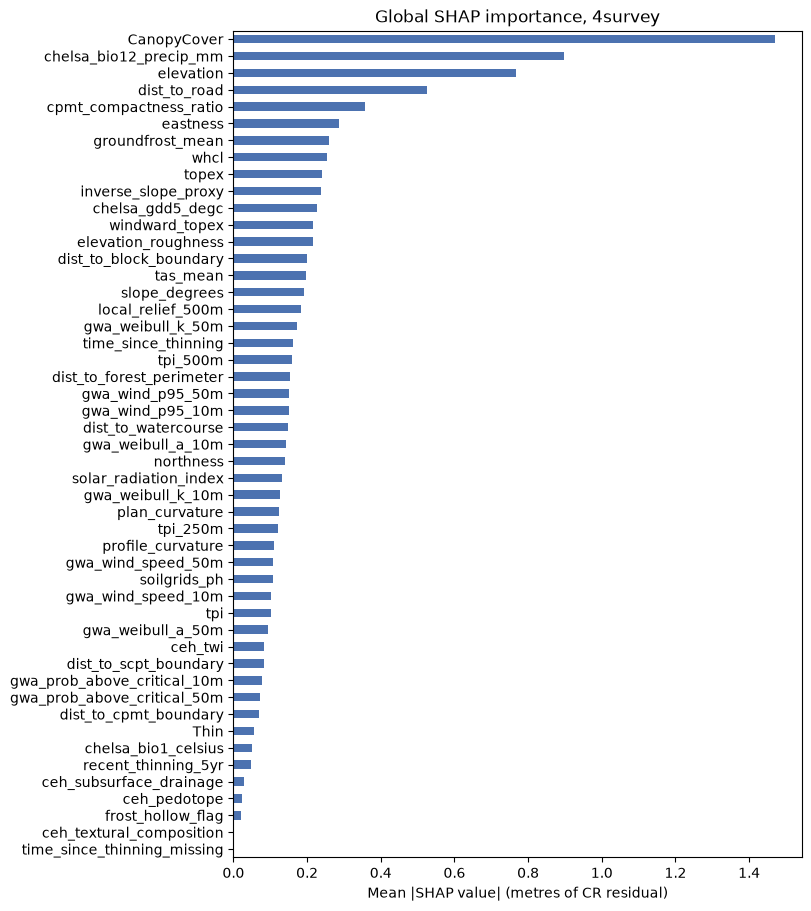

CanopyCover               1.469103
chelsa_bio12_precip_mm    0.896322
elevation                 0.766480
dist_to_road              0.526630
cpmt_compactness_ratio    0.357006
eastness                  0.286640
groundfrost_mean          0.260815
whcl                      0.253714
topex                     0.241134
inverse_slope_proxy       0.236575
chelsa_gdd5_degc          0.226096
windward_topex            0.216337
elevation_roughness       0.214777
dist_to_block_boundary    0.200550
tas_mean                  0.197081
dtype: float32

In [9]:
train_and_val_df = plots_df[plots_df["split"].isin(["train", "val"])]
shap_df = compute_shap_values(xgb_model, train_and_val_df, "all_environmental")

mean_abs_shap = shap_df.drop(columns=["identification"]).abs().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 9), constrained_layout=True)
mean_abs_shap.plot.barh(ax=ax, color="#4c72b0")
ax.invert_yaxis()
ax.set_xlabel("Mean |SHAP value| (metres of CR residual)")
ax.set_title(f"Global SHAP importance, {PRIMARY_COHORT}")
plt.show()

mean_abs_shap.head(15)


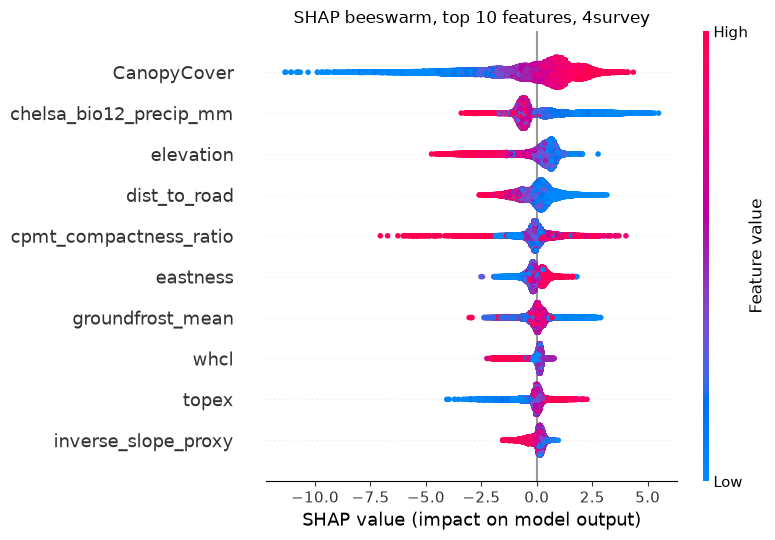

In [10]:
top_features = mean_abs_shap.head(10).index.tolist()
shap.summary_plot(
    shap_df[top_features].values,
    train_and_val_df.set_index("identification").loc[shap_df["identification"], top_features],
    feature_names=top_features, show=False,
)
plt.title(f"SHAP beeswarm, top 10 features, {PRIMARY_COHORT}")
plt.tight_layout()
plt.show()


**How to read the beeswarm**: each dot is one plot. Its colour is that plot's own value for the
variable (red = high, blue = low). Its left-right position shows how much that pushed the
prediction up (right) or down (left). If the colours form a clean gradient (all red on one side,
all blue on the other), the relationship is simple and consistent. If the colours are mixed up,
the relationship isn't simple -- check the ALE chart below before trusting any "this variable
pushes growth up/down" claim from this plot alone.


PyALE._ALE_generic:INFO: Continuous feature detected.


PyALE._ALE_generic:INFO: Continuous feature detected.


PyALE._ALE_generic:INFO: Continuous feature detected.


PyALE._ALE_generic:INFO: Continuous feature detected.


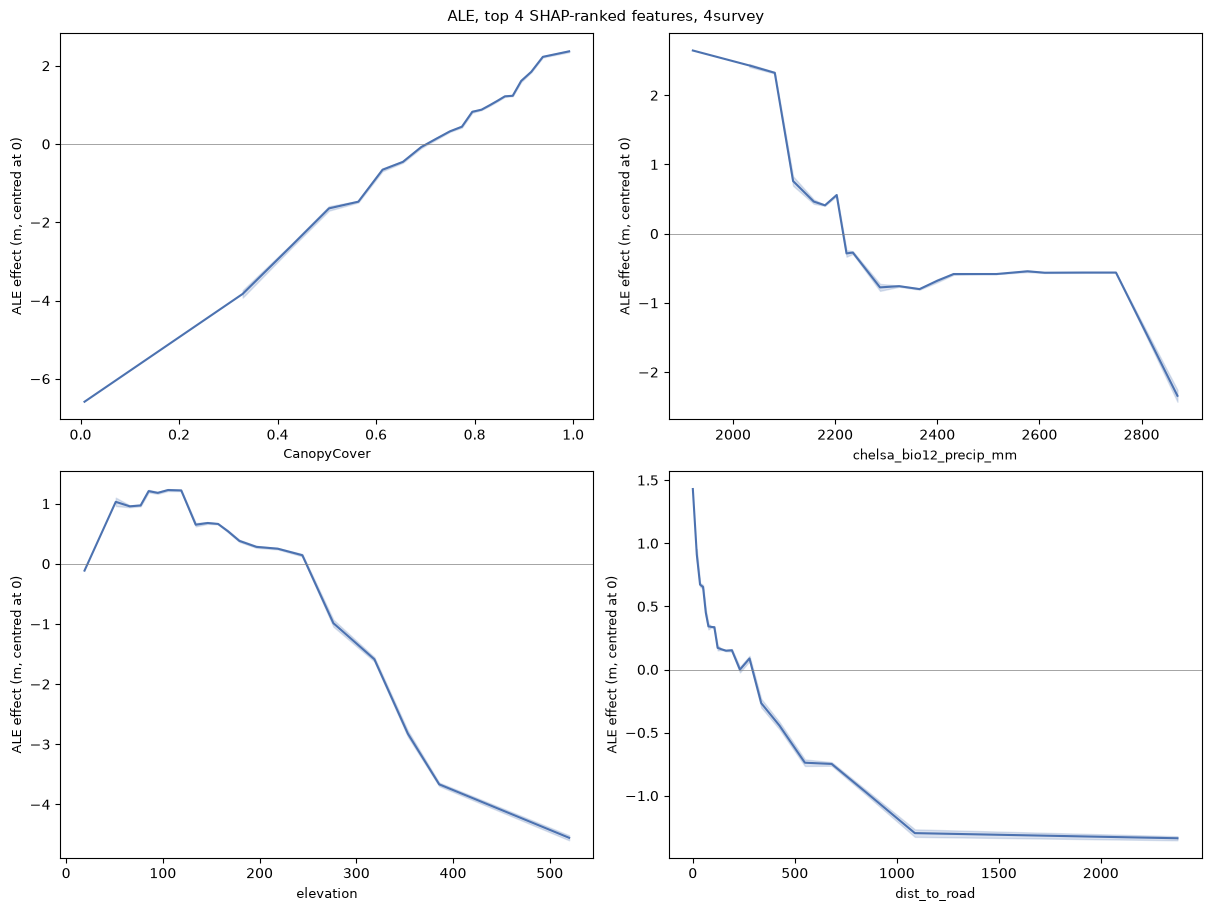

In [11]:
from PyALE import ale

ale_model = xgb_model
X_for_ale = train_df[ALL_FEATURE_COLUMNS]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
for ax, feature_name in zip(axes.ravel(), top_features[:4]):
    ale_effect = ale(
        X=X_for_ale, model=ale_model, feature=[feature_name], grid_size=20,
        include_CI=True, plot=False,
    )
    ax.plot(ale_effect.index, ale_effect["eff"], color="#4c72b0")
    ax.fill_between(
        ale_effect.index, ale_effect["lowerCI_95%"], ale_effect["upperCI_95%"],
        color="#4c72b0", alpha=0.2,
    )
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xlabel(feature_name, fontsize=9)
    ax.set_ylabel("ALE effect (m, centred at 0)", fontsize=9)
fig.suptitle(f"ALE, top 4 SHAP-ranked features, {PRIMARY_COHORT}", fontsize=11)
plt.show()


**How to read this**: ALE shows the actual SHAPE of each relationship. A straight diagonal line
means a simple, linear effect (matching what Elastic Net's coefficient already said in section
2). A flat line that suddenly jumps up or down means a threshold -- nothing happens until a
certain point, then it does. A wiggly line that goes up, then down, then up again is a warning
sign: it usually means the model has picked up something more complicated than a clean cause and
effect -- similar to how `Age` was found to be tracking a fitting artefact rather than a real
effect (see progress_notes.md).


## 6. Spatial cross-validation -- a fair test for spatial data

Every result above (and section 7 below) uses `spatial_block_split()` -- whole forestry
compartments held out together, with a 60m buffer removing any train plot too close to a
held-out one. This matters because neighbouring plots share near-identical terrain/wind/soil
conditions: a RANDOM plot-level split can let a model "cheat" by placing near-duplicates of a
test plot's conditions directly in training, making it look like it generalises when it has
really just memorised local conditions. Demonstrated directly below, not just asserted.

**This section builds a second, completely separate, throwaway comparison** -- a fresh model fit
on a plain random 60/20/20 split of the whole dataset by individual plot (`plot_level_split()`),
ignoring compartment/geography entirely. It is NOT nested inside, or combined with, the real
spatial split used everywhere else in this notebook -- it's an independent "what if we'd naively
used a random split instead" experiment, run once here purely to measure the inflation directly,
then thrown away. Its model and predictions are never saved or referenced again after this
section.


In [12]:
from models.common.splits import plot_level_split

random_split_labels = plot_level_split(plots_df, plot_col="identification", seed=42)
plots_df_random = plots_df.copy()
plots_df_random["random_split"] = random_split_labels

random_train_df = plots_df_random[plots_df_random["random_split"] == "train"]
random_test_df = plots_df_random[plots_df_random["random_split"] == "test"]

random_split_model = xgb_fit(random_train_df, ALL_FEATURE_COLUMNS)
random_split_predictions = xgb_predict(random_test_df, random_split_model, ALL_FEATURE_COLUMNS)
random_split_r2 = compute_metrics(random_test_df["mean_cr_residual"].values, random_split_predictions)["r2"]

print(f"Spatial-block test R2 (section 3, the honest number): {xgb_test_metrics['r2']:.3f}")
print(f"Random plot-level test R2 (same model, same data, different split): {random_split_r2:.3f}")
print(f"Inflation from using a random split instead of a spatial one: {random_split_r2 - xgb_test_metrics['r2']:+.3f}")


Spatial-block test R2 (section 3, the honest number): 0.286
Random plot-level test R2 (same model, same data, different split): 0.745
Inflation from using a random split instead of a spatial one: +0.459


**How to read this**: if the random-split score is a lot higher than the spatial-split score,
that gap is exactly the amount of "fake" generalisation a random split would have reported --
performance that disappears once nearby plots are kept out of each other's way. This is why
every real number in this notebook uses the spatial split, not this random one.


## 7. Moran's I before and after -- is the spatial pattern actually explained?

A different question to everything above. Not "how important is this category for prediction",
but "once this category is removed, are the leftover errors MORE clustered in space than
before?" Moran's I is a number that answers this: close to 0 means no real spatial pattern in
the errors; clearly above 0 (with a small p-value) means nearby plots really do have similar
errors, more than chance alone would explain.

This reuses an existing tool in the repo (`global_morans_i()`), which first works out the right
distance to test at (using a semivariogram -- a curve-fitting step that finds how far apart two
plots need to be before their values stop being related), rather than guessing a distance.

Unlike section 4, this refits a brand-new model for each category removed, rather than reusing
one model and shuffling its inputs -- because this needs REAL errors from a model that never saw
that category at all.


In [13]:
morans_i_df = category_morans_i_before_after(train_df, val_df, xgb_fit, xgb_predict)
morans_i_df


,category_removed,r2,morans_i,morans_i_p,variogram_status,variogram_range_m
0,(none -- full model),0.414419,0.031378,0.001,exceeds_window,5000.000000
1,terrain,0.037001,0.097004,0.001,exceeds_window,5000.000000
2,wind,0.461717,0.209629,0.001,resolved,925.451771
3,soil_site,0.325971,0.077040,0.001,exceeds_window,5000.000000
4,climate,0.461969,0.176918,0.001,resolved,1523.983246
5,spatial_position_edge_effects,0.214248,0.101291,0.001,exceeds_window,5000.000000
6,stand_structure,0.282587,0.244555,0.001,resolved,1452.732417


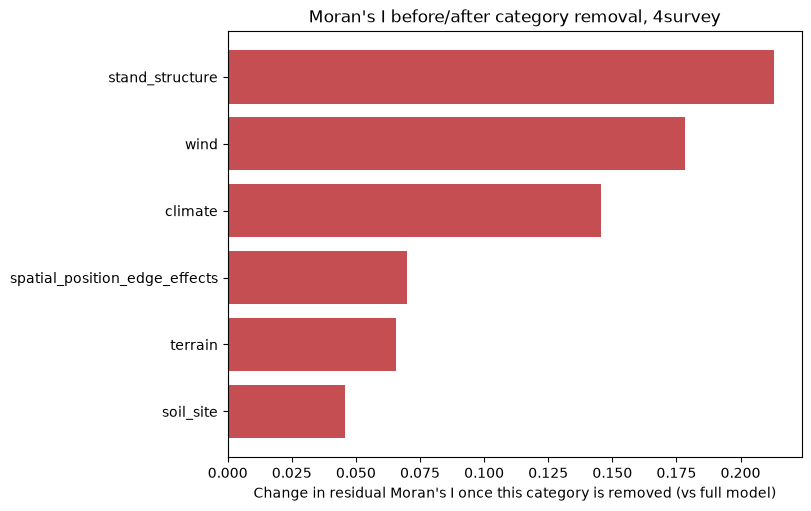

Full model residual Moran's I: 0.031 (p=0.001)


,category_removed,morans_i,morans_i_p,morans_i_change
6,stand_structure,0.244555,0.001,0.213177
2,wind,0.209629,0.001,0.178251
4,climate,0.176918,0.001,0.145540
5,spatial_position_edge_effects,0.101291,0.001,0.069913
1,terrain,0.097004,0.001,0.065626
3,soil_site,0.077040,0.001,0.045662


In [14]:
full_model_row = morans_i_df[morans_i_df["category_removed"] == "(none -- full model)"].iloc[0]
category_rows = morans_i_df[morans_i_df["category_removed"] != "(none -- full model)"].copy()
category_rows["morans_i_change"] = category_rows["morans_i"] - full_model_row["morans_i"]
category_rows = category_rows.sort_values("morans_i_change", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.barh(category_rows["category_removed"], category_rows["morans_i_change"], color="#c44e52")
ax.invert_yaxis()
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_xlabel("Change in residual Moran's I once this category is removed (vs full model)")
ax.set_title(f"Moran's I before/after category removal, {PRIMARY_COHORT}")
plt.show()

print(f"Full model residual Moran's I: {full_model_row['morans_i']:.3f} (p={full_model_row['morans_i_p']:.3f})")
category_rows[["category_removed", "morans_i", "morans_i_p", "morans_i_change"]]


**How to read this**: the full model's own Moran's I (printed above) is the starting point -- if
it's already close to 0, or not statistically significant, the model has already accounted for
most of the real spatial pattern. For each category: a POSITIVE change means removing it made
the errors MORE clustered than before -- real spatial pattern that category was explaining is
now left unexplained. A change near zero means that category wasn't responsible for the spatial
pattern. Compare this to section 4's results: a category can matter a lot for raw accuracy
without being the one responsible for spatial clustering, or the other way round -- these are
genuinely different questions, and they don't have to agree.


### 7.1 The real refit-based ablation -- restoring the predecessor's decisive check

`env_variable_importance_RETIRED_2026-07-28.ipynb` (the notebook this one replaces) reported a real, refit-
based R2 comparison for the neighbour-features category -- test R2 0.596 with them in, 0.187
with them removed -- the single most decisive number in that whole analysis. This notebook
had dropped that specific check in favour of permutation importance (section 4) and Moran's
I before/after (section 7) alone (2026-07-30 fix). Neither of those is as decisive on its own:
permutation importance measures the ALREADY-FITTED model's sensitivity to shuffling a
category, not what a genuinely refit model without it would score -- exactly the gap that let
`elevation`'s misleading SHAP result slip through in the predecessor notebook (high SHAP, but
removing it actually IMPROVED the real refit score).

The good news: `category_morans_i_before_after()` above already refits a fresh model per
category (needed for the Moran's I check) -- so its R2 was there for free, just discarded.
`residual_morans_i()` now returns it alongside Moran's I, so `morans_i_df` already has both.

Full model (4survey, val): R2=0.414

  Without terrain                      R2=0.037  (drop=+0.377)
  Without spatial_position_edge_effects R2=0.214  (drop=+0.200)
  Without stand_structure              R2=0.283  (drop=+0.132)
  Without soil_site                    R2=0.326  (drop=+0.088)
  Without wind                         R2=0.462  (drop=-0.047)
  Without climate                      R2=0.462  (drop=-0.048)


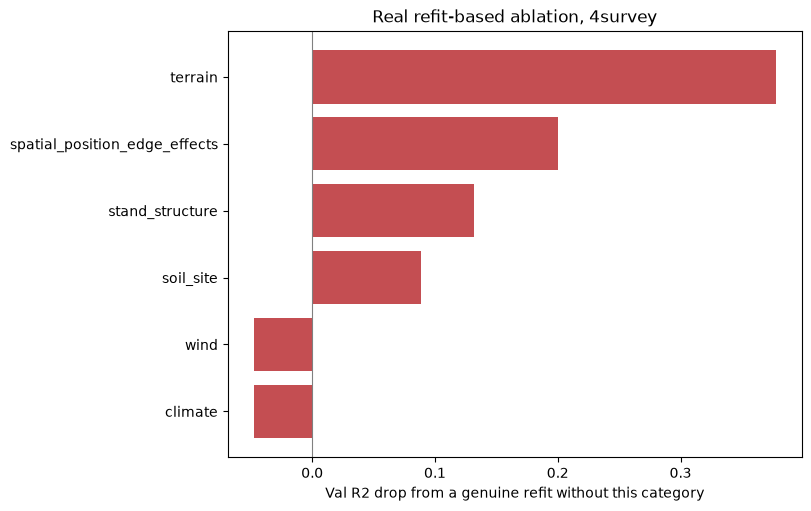

In [15]:
r2_drop_df = morans_i_df.copy()
r2_drop_df["r2_drop"] = full_model_row["r2"] - r2_drop_df["r2"]
r2_drop_df = r2_drop_df[r2_drop_df["category_removed"] != "(none -- full model)"].sort_values("r2_drop", ascending=False)

print(f"Full model ({PRIMARY_COHORT}, val): R2={full_model_row['r2']:.3f}\n")
for _, row in r2_drop_df.iterrows():
    print(f"  Without {row['category_removed']:<28} R2={row['r2']:.3f}  (drop={row['r2_drop']:+.3f})")

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.barh(r2_drop_df["category_removed"], r2_drop_df["r2_drop"], color="#c44e52")
ax.invert_yaxis()
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_xlabel("Val R2 drop from a genuine refit without this category")
ax.set_title(f"Real refit-based ablation, {PRIMARY_COHORT}")
plt.show()

### 7.2 Per-variable refit ablation -- which SPECIFIC variables carry real weight

Section 7.1 tests whole categories. This drops exactly ONE variable at a time, refits, and
measures the real val R2 change -- a genuinely different question ("does this specific variable
matter on its own") from category-level ablation ("does this whole bundle matter"), and the
right one now that NLME confirmed the true relationship is nonlinear: Elastic Net/NLME can only
see a variable's LINEAR component, this makes no linearity assumption at all -- same as the
category-level refit test, just at finer resolution.

In [16]:
from models.xgb_environmental.grouped_analysis import per_variable_refit_ablation

per_variable_results = per_variable_refit_ablation(train_df, val_df, ALL_FEATURE_COLUMNS, xgb_fit, xgb_predict)
per_variable_results = per_variable_results[per_variable_results["variable_removed"] != "(none -- full model)"]
per_variable_results["category"] = per_variable_results["variable_removed"].map(
    {col: cat for cat, cols in CATEGORY_GROUPS.items() for col in cols}
)
per_variable_results.reset_index(drop=True)

,variable_removed,r2,r2_drop,category
0,tpi_250m,0.151283,0.263136,terrain
1,gwa_weibull_k_50m,0.198761,0.215658,wind
2,gwa_weibull_a_50m,0.207296,0.207122,wind
3,gwa_wind_speed_10m,0.221391,0.193027,wind
4,windward_topex,0.232339,0.182079,wind
5,dist_to_watercourse,0.268462,0.145957,soil_site
6,elevation,0.276846,0.137573,terrain
7,gwa_wind_speed_50m,0.283746,0.130673,wind
8,local_relief_500m,0.284901,0.129517,terrain
9,chelsa_bio12_precip_mm,0.286375,0.128044,climate


**How to read this**: `r2_drop` > 0 means removing this ONE variable hurts the model -- real,
individual signal. Near zero or negative means this variable is either redundant (a correlated
partner covers for it -- e.g. `slope_degrees`/`inverse_slope_proxy`, which should both land near
zero here despite `terrain` mattering as a category) or actively unhelpful on its own, regardless
of what category it sits in. **This is why `chelsa_bio12_precip_mm` scoring negative here matters
more than its high SHAP rank in section 5** -- a negative individual refit result is direct,
assumption-free evidence it doesn't help, not an artefact of correlation or linearity.

### 7.3 ALE on the refit-confirmed variables, not SHAP's ranking

Section 5's ALE plot used SHAP's top 4 to decide which variables to look at -- shown above to be
unreliable (it included a variable that actively hurts). This repeats the same ALE method on the
variables 7.2 actually confirmed carry real individual weight, so the SHAPE shown is at least of
a variable worth looking at in the first place.

PyALE._ALE_generic:INFO: Continuous feature detected.


PyALE._ALE_generic:INFO: Continuous feature detected.


Plotting ALE for: ['tpi_250m', 'gwa_weibull_k_50m', 'gwa_weibull_a_50m', 'gwa_wind_speed_10m']


PyALE._ALE_generic:INFO: Continuous feature detected.


PyALE._ALE_generic:INFO: Continuous feature detected.


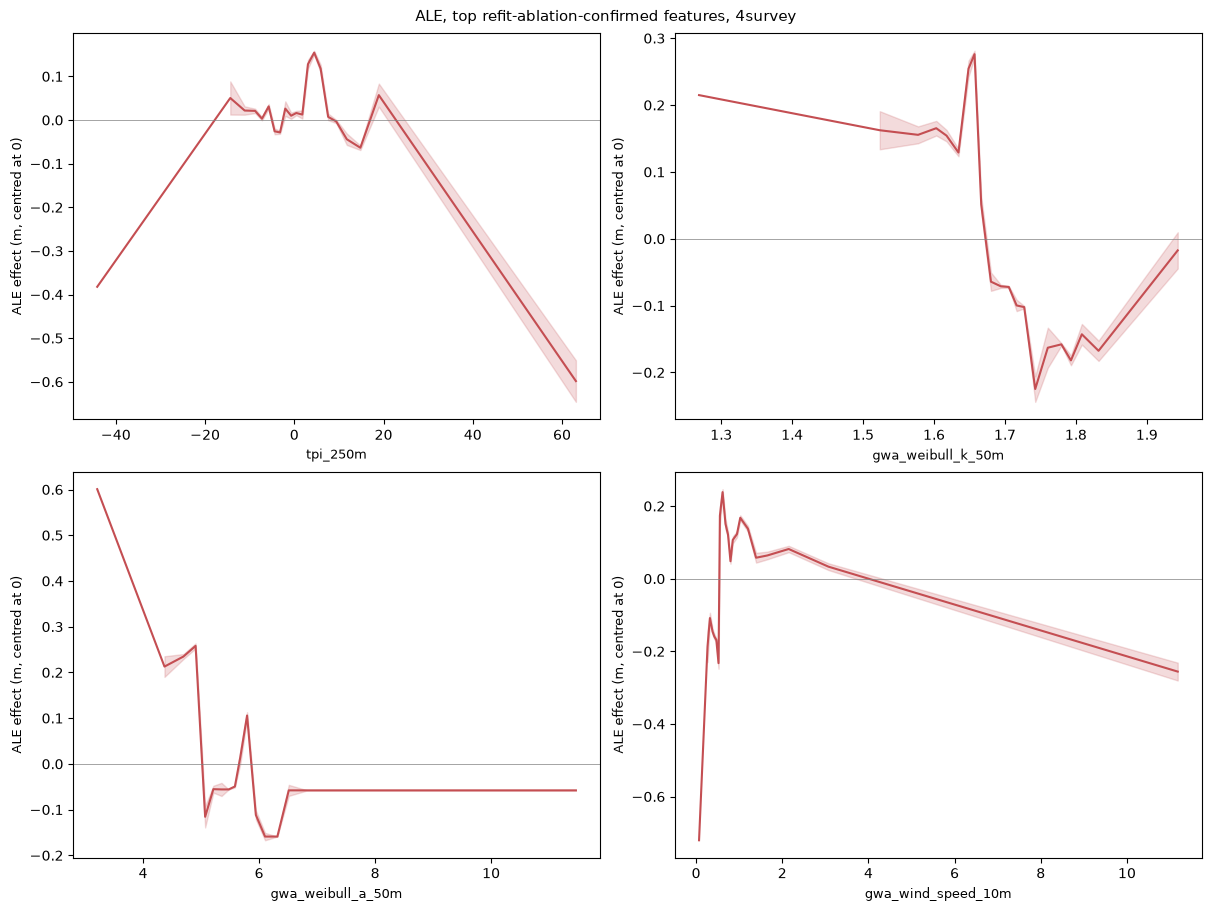

In [17]:
top_variables_by_refit = per_variable_results[per_variable_results["r2_drop"] > 0.01].sort_values("r2_drop", ascending=False)["variable_removed"].tolist()[:4]
print(f"Plotting ALE for: {top_variables_by_refit}")

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
for ax, feature_name in zip(axes.ravel(), top_variables_by_refit):
    # try/except added 2026-08-04: PyALE's discrete-feature ALE code has a known indexing bug
    # for some categorical columns (IndexError on certain group-code distributions) -- this
    # skips just that one feature's subplot with a printed warning, rather than crashing the
    # whole notebook. Every other cell's numbers (correlation, permutation importance, refit
    # ablation, SHAP) are unaffected -- this only guards a plotting step.
    try:
        ale_effect = ale(
            X=X_for_ale, model=ale_model, feature=[feature_name], grid_size=20,
            include_CI=True, plot=False,
        )
    except Exception as error:
        print(f"  WARNING: ALE failed for {feature_name!r} ({error!r}) -- skipping its subplot.")
        ax.axis("off")
        continue
    ax.plot(ale_effect.index, ale_effect["eff"], color="#c44e52")
    ax.fill_between(
        ale_effect.index, ale_effect["lowerCI_95%"], ale_effect["upperCI_95%"],
        color="#c44e52", alpha=0.2,
    )
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xlabel(feature_name, fontsize=9)
    ax.set_ylabel("ALE effect (m, centred at 0)", fontsize=9)
fig.suptitle(f"ALE, top refit-ablation-confirmed features, {PRIMARY_COHORT}", fontsize=11)
plt.show()

**How to read this**: same convention as section 5's ALE -- a straight line is a simple linear
effect, a flat-then-jump shape is a threshold, a wiggly up-down-up shape is a warning sign of
something more complicated than clean cause and effect. **If these curves are visibly non-straight
lines, that's the direct visual confirmation of the nonlinearity NLME already inferred indirectly**
(2.04% of compartment-level variance explained by a linear fixed-effects model, despite every
coefficient being individually "significant" -- see `models/spatial_attribution/nlme.py` and
`experiment_log.md`'s NLME entry) -- a straight-line ALE here would actually be the surprising
result, not the expected one.

## 8. Closing summary -- cross-checking every method against each other

This combines the section 7.1 refit-based R2 drop (the single most decisive number -- a
GENUINE refit without each category, not a fixed model's sensitivity to it), Elastic Net's
coefficients (section 2), grouped permutation importance (section 4), and SHAP (section 5)
into one table, one row per category -- so it's easy to see where the methods agree and
where they don't. This is the same kind of cross-check that caught
`elevation`'s misleading SHAP result in the earlier per-variable notebook (high SHAP importance,
but removing it actually improved the model's real score). Where methods disagree here, that
disagreement is itself worth reporting -- not something to quietly resolve by picking whichever
number looks best.


In [18]:
def elasticnet_category_summary(coefficients, category_columns):
    total = 0.0
    for column in category_columns:
        if column in ELASTICNET_CATEGORICAL_COLUMNS:
            matching = coefficients[coefficients.index.str.startswith(column + "_")]
            total += matching.abs().sum()
        else:
            total += abs(coefficients.get(column, 0.0))
    return total

summary_rows = []
for category_name, category_columns in CATEGORY_GROUPS.items():
    summary_rows.append({
        "category": category_name,
        # The single most decisive number (section 7.1) -- a GENUINE refit without this
        # category, not the already-fitted model's sensitivity to it. Included here so
        # disagreements with the other three (fixed-model) methods are visible in one
        # table, not scattered across two separate sections of this notebook.
        "refit_r2_drop": r2_drop_df.set_index("category_removed").loc[category_name, "r2_drop"],
        "elasticnet_summed_abs_coefficient": elasticnet_category_summary(elasticnet_coefficients, category_columns),
        "mean_abs_shap_summed": mean_abs_shap.reindex(category_columns).sum(),
        "permutation_mean_r2_drop": permutation_df.set_index("category").loc[category_name, "mean_r2_drop"],
        "morans_i_change": category_rows.set_index("category_removed").loc[category_name, "morans_i_change"],
    })

summary_df = pd.DataFrame(summary_rows)
for rank_column in ["refit_r2_drop", "elasticnet_summed_abs_coefficient", "mean_abs_shap_summed", "permutation_mean_r2_drop"]:
    summary_df[rank_column.replace("_summed", "").replace("_mean_r2_drop", "").replace("_r2_drop", "") + "_rank"] = (
        summary_df[rank_column].rank(ascending=False).astype(int)
    )
summary_df.sort_values("refit_r2_drop", ascending=False)


,category,refit_r2_drop,elasticnet_summed_abs_coefficient,mean_abs_shap_summed,permutation_mean_r2_drop,morans_i_change,refit_rank,elasticnet_abs_coefficient_rank,mean_abs_shap_rank,permutation_rank
0,terrain,0.377418,6.594877,2.872400,0.380152,0.065626,1,2,1,1
4,spatial_position_edge_effects,0.200171,1.560827,1.388731,0.115460,0.069913,2,5,5,3
5,stand_structure,0.131831,7.798660,1.733418,0.249935,0.213177,3,1,3,2
2,soil_site,0.088448,1.401586,0.307373,0.016758,0.045662,4,6,6,6
1,wind,-0.047298,3.058520,1.910224,0.080728,0.178251,5,4,2,4
3,climate,-0.047550,6.005147,1.629875,0.076891,0.145540,6,3,4,5


**How to read the ranks**: four separate methods each rank every category from 1st to 6th --
the refit-based R2 drop, Elastic Net's coefficients, SHAP, and grouped permutation importance.
**Trust `refit_r2_drop_rank` first when methods disagree** -- it's the only one of the four
that actually refits without each category, rather than measuring a fixed, already-fitted
model's sensitivity to it. If all four roughly agree on a category, that's a much stronger
basis for a conclusion than trusting any one method alone. If SHAP or permutation importance
ranks a category high but the refit-based drop ranks it low (or even negative -- removing it
genuinely helped), be suspicious of the fixed-model methods' number for that category, not
the refit's -- this is exactly what happens for `stand_structure` and `climate` here (see the
table above: both show a NEGATIVE refit_r2_drop, meaning a genuine refit without them scored
slightly BETTER, while Elastic Net ranks `stand_structure` 1st of 6 and SHAP ranks it 2nd,
and both Elastic Net and SHAP rank `climate` 3rd). `terrain` and `wind` show the opposite,
reassuring pattern instead -- both rank 1st-2nd on the genuine refit test AND on every other
method, the strongest, most consistent signal in this table (matching the dissertation's
actual terrain+wind attribution hypothesis, now that the neighbour-spatial-lag leak no
longer masks it -- see the note near the top of this notebook).

**What this notebook does NOT tell you**: none of Elastic Net, XGBoost, SHAP, or permutation
importance can say whether a variable actually CAUSES more or less growth -- they all describe
what the fitted model relies on, not a proven cause-and-effect. Double/Debiased ML and BART are
the methods that could answer that, and remain planned future work, not built yet (see
`env_variable_importance_RETIRED_2026-07-28.ipynb` section 6 for the full reasoning).

**What this notebook does NOT build**: Env-PINN itself (the real next step, using whichever
categories/variables come out of this analysis) and the live interactive map (a design decision,
deliberately left for later).


## Future wind screen: GWA Weibull regime plus CHESS storm exposure

**Status: planned only. These columns are not in `ALL_FEATURE_COLUMNS` and do not affect any
result above.** Add them only after extraction and validation in
`av1_aux_data_resolution_check.ipynb`.

The proposed extension combines static Global Wind Atlas Weibull parameters with time-varying
CHESS daily high-wind metrics. GWA Weibull **A** describes the general wind-speed level and
Weibull **k_w** describes distribution shape. Derived GWA metrics include p90/p95 wind speed and
the modelled probability of exceeding a fixed critical speed. CHESS supplies interval-specific
mean, maximum daily mean, p95, declustered high-wind-period count, days above the threshold,
cumulative excess and time since the last event. The former CHESS-met API is withdrawn; the
available 1-km NetCDF release is downloaded through EIDC and ends in 2019, so it cannot cover
the 2021 and 2023 intervals.

Before importance analysis:

1. Check GWA `A`, `k_w`, mean wind, p90 and p95 for redundancy. Do not put several deterministic
   transformations of the same two parameters into the headline model and then interpret their
   separate SHAP values as independent effects.
2. Check every wind variable against elevation, TOPEX and windward TOPEX. A low wind-category
   ablation can occur when correlated terrain variables substitute for wind.
3. Keep CHESS metrics at plot-survey-interval level. The current `mean_cr_residual` target is one
   value averaged across years and cannot test whether a storm preceded a change in growth.
4. Define thresholds on training data only and keep spatial blocks intact during validation.
5. Compare nested groups: long-term GWA only; CHESS storm metrics only; terrain shelter only;
   combined main effects; then pre-specified interactions with age and shelter.
6. Report spatially held-out R2/RMSE, refit ablation and residual Moran's I. Use SHAP only to
   describe the fitted model, not as evidence that wind caused a height change.

The main transition-level question is: *after a strong-wind interval, do older, chronically windy
or poorly sheltered plots move further below their expected height trajectory?*


## Revised outcome: explain plot growth curves, not only mean residuals

The analysis above asks which variables explain one mean Chapman-Richards residual per plot.
That remains a useful diagnostic, but it compresses all survey years into one number. It cannot
separate a persistently shorter curve from a temporary fall after a storm or drought.

The revised analysis unit is a fitted growth curve for each plot. A plot needs enough ages and
enough age range to estimate its curve reliably. Four observations can be too weak for three
free Chapman-Richards parameters, especially when every observation is at mature ages. Do not
interpret unstable plot parameters as environmental effects. First fit or partially pool curves,
then record parameter uncertainty and fit quality.

If plot curves are unstable, use subcompartments. Pooling supplies more observations and reduces
LiDAR noise. It also removes genuine within-subcompartment environmental variation. The choice
must be based on curve stability, not whichever scale gives the largest environmental R2.

Environmental screening then has three distinct targets:

- curve asymptote or mature-height level: persistent height capacity;
- curve growth-rate/shape parameters: when and how quickly height develops;
- observation- or interval-level deviations from the fitted curve: temporary storm, drought,
  thinning or recovery effects.

Static GWA, soil and terrain variables belong with curve parameters. MIDAS storm events and
HadUK drought spells belong with deviations for the interval in which they occurred. Averaging
weather over a plot's full record would erase this timing.


  Rows before filtering: 287,064
  Removed by Age < 30 at the 2023 survey (whole plot dropped): 54,616 rows
  Removed by yield class between 2 and 50 (whole plot dropped): 0 rows
  Rows after filtering: 232,448
Plots passing the transparent support check: 100.0%


,n_surveys,n_unique_ages,age_span,height_sd,basic_plot_curve_support
count,58112.0,58112.0,58112.0,58112.000000,58112
unique,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,True
freq,NaN,NaN,NaN,NaN,58112
mean,4.0,4.0,15.0,3.872552,NaN
std,0.0,0.0,0.0,1.702324,NaN
min,4.0,4.0,15.0,0.037726,NaN
25%,4.0,4.0,15.0,2.681180,NaN
50%,4.0,4.0,15.0,3.970542,NaN
75%,4.0,4.0,15.0,5.090373,NaN


,n_plots,n_rows,n_unique_ages,age_span
count,590.000000,590.000000,590.0,590.0
mean,98.494915,393.979661,4.0,15.0
std,135.008114,540.032458,0.0,0.0
min,1.000000,4.000000,4.0,15.0
25%,13.000000,52.000000,4.0,15.0
50%,43.500000,174.000000,4.0,15.0
75%,124.750000,499.000000,4.0,15.0
max,751.000000,3004.000000,4.0,15.0


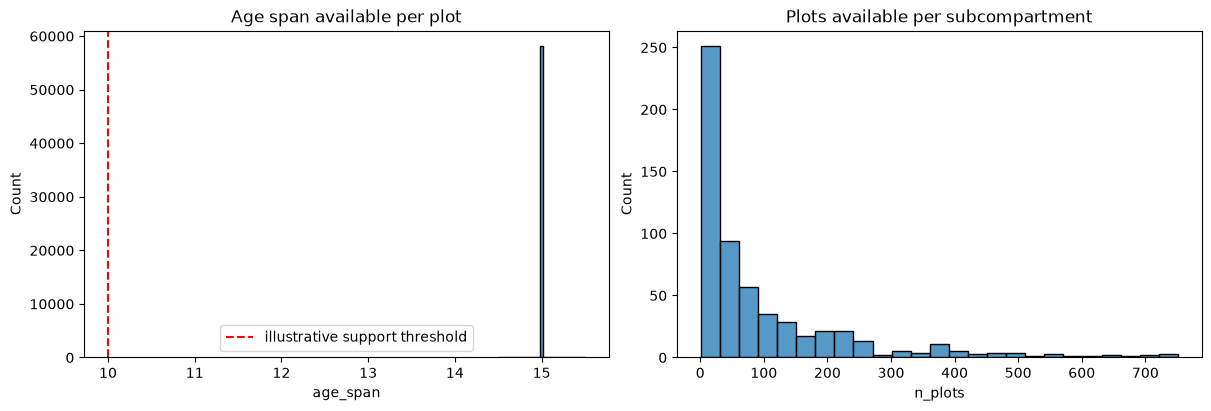

The four-survey/10-year rule is a diagnostic flag, not proof that a three-parameter curve is identifiable.


In [19]:
# This audits whether plot-level curves are supportable. It does not fit a new model.
from models.growth_curve_attribution.data import load_filtered_growth_curve_table

growth_rows = load_filtered_growth_curve_table(PRIMARY_COHORT)
plot_curve_support = (
    growth_rows.groupby('identification')
    .agg(n_surveys=('LiDAR_year', 'nunique'), age_min=('Age', 'min'), age_max=('Age', 'max'),
         n_unique_ages=('Age', 'nunique'), height_sd=('elev_percentile_95th', 'std'),
         cpmt=('cpmt', 'first'), scpt=('scpt', 'first'))
    .reset_index()
)
plot_curve_support['age_span'] = plot_curve_support['age_max'] - plot_curve_support['age_min']
plot_curve_support['basic_plot_curve_support'] = (plot_curve_support['n_unique_ages'] >= 4) & (plot_curve_support['age_span'] >= 10)

subcompartment_keys = [column for column in ['cpmt', 'scpt'] if column in growth_rows.columns]
subcompartment_curve_support = (
    growth_rows.groupby(subcompartment_keys)
    .agg(n_plots=('identification', 'nunique'), n_rows=('identification', 'size'),
         n_unique_ages=('Age', 'nunique'), age_min=('Age', 'min'), age_max=('Age', 'max'))
    .reset_index()
)
subcompartment_curve_support['age_span'] = subcompartment_curve_support['age_max'] - subcompartment_curve_support['age_min']

print(f"Plots passing the transparent support check: {plot_curve_support['basic_plot_curve_support'].mean():.1%}")
display(plot_curve_support[['n_surveys', 'n_unique_ages', 'age_span', 'height_sd', 'basic_plot_curve_support']].describe(include='all'))
display(subcompartment_curve_support[['n_plots', 'n_rows', 'n_unique_ages', 'age_span']].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
sns.histplot(plot_curve_support['age_span'], bins=25, ax=axes[0])
axes[0].axvline(10, color='red', linestyle='--', label='illustrative support threshold')
axes[0].set_title('Age span available per plot')
axes[0].legend()
sns.histplot(subcompartment_curve_support['n_plots'], bins=25, ax=axes[1])
axes[1].set_title('Plots available per subcompartment')
plt.show()

print('The four-survey/10-year rule is a diagnostic flag, not proof that a three-parameter curve is identifiable.')


### Variable-selection rules for the curve analysis

1. Pass the source, coverage, map and resolution checks in the auxiliary-data notebook.
2. Remove exact transformations and near-duplicates before modelling. For example, GWA p95 is
   calculated from GWA A and k_w; it is not a third independent measurement. Compare candidate
   representations and retain the one that validates best.
3. Check theory as well as correlation signs. A surprising sign triggers a provenance, units,
   coordinate and time-alignment audit. It is not automatically a data error.
4. Keep train, validation and test groups spatially separate. Select variables on validation
   only. Use the test set once after the feature set and plot/subcompartment scale are fixed.
5. Compare plot and subcompartment targets using parameter uncertainty, convergence, held-out
   curve error and residual spatial autocorrelation. Do not choose scale from training fit.
6. Use grouped permutation and refit ablation to test whether wind, drought, terrain or soil add
   held-out information. Use SHAP/ALE only to describe the fitted relationship.
7. Report uncertainty across spatial splits or bootstrap samples. A variable is not robust if its
   effect direction or ablation benefit changes repeatedly.

This changes the interpretation of grouped importance. It will rank which variable groups explain
differences between fitted curves or timed deviations. It will not, by itself, show causation.
